In [18]:
!pip install playwright
!playwright install --with-deps firefox

  Using cached pyee-13.0.0-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 6.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 6.9 MB/s eta 0:00:00a 0:00:01
Using cached pyee-13.0.0-py3-none-any.whl (15 kB)

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
(node:44076) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
91.5 MiB [                    ] 0% 0.0s91.5 MiB [                    ] 0% 23.4s91.5 MiB [                    ] 0% 19.1s91.5 MiB [                    ] 0% 18.6s91.5 MiB [                    ] 0% 17.0s91.5 MiB [                    ] 0% 16.2s91.5 MiB [                    ] 0% 15.6s91.5 MiB [            

In [19]:
!playwright install firefox


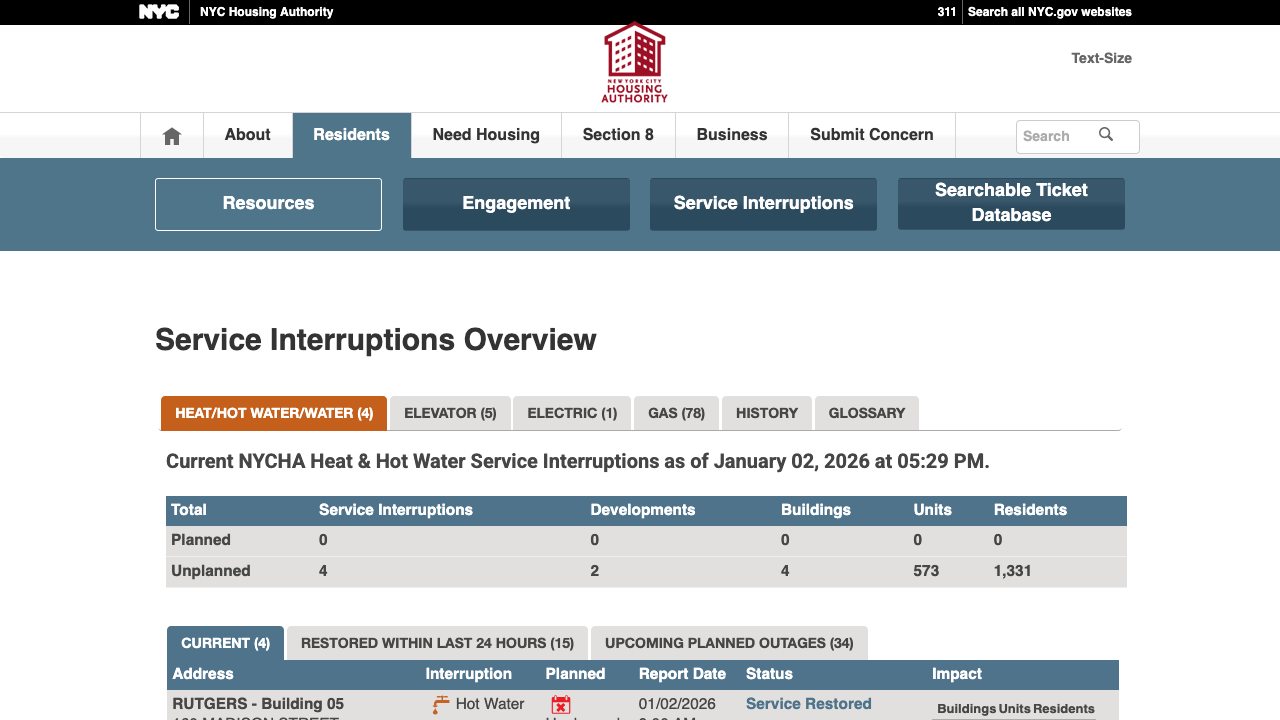

In [20]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def load_page():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        # Go to NYCHA Outages page
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Take a screenshot so we know it loaded
        await page.screenshot(path="nycha_page.png")

        await browser.close()

# Run the async function
await load_page()

# Display screenshot
display(Image(filename="nycha_page.png"))


In [21]:
from playwright.async_api import async_playwright
import asyncio

async def find_select_ids():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        
        select_ids = await page.eval_on_selector_all(
            "select",
            "elements => elements.map(e => ({id: e.id, name: e.name}))"
        )

        print(select_ids)

        await browser.close()

await find_select_ids()


[{'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpBoroughs', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpBoroughs'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpDevelopments', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpDevelopments'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpBuildings', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpBuildings'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpAddressess', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpAddressess'}, {'id': 'ctl00_ContentPlaceHolder1_historicalOutagesList_drpOutageType', 'name': 'ctl00$ContentPlaceHolder1$historicalOutagesList$drpOutageType'}]


In [22]:
from playwright.async_api import async_playwright
import asyncio

async def inspect_frames():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=True)
        page = await browser.new_page()
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Loop through frames
        for idx, frame in enumerate(page.frames):
            print("\n=== FRAME", idx, "URL:", frame.url, "===")
            try:
                # Try to get the outer HTML
                html = await frame.content()
                # Print only first 500 chars (to avoid overwhelming output)
                print(html[:500])
            except:
                print("Could not read frame content")

        await browser.close()

await inspect_frames()



=== FRAME 0 URL: https://my.nycha.info/Outages/Outages.aspx ===
<!DOCTYPE html><html class=" js no-touch csstransforms csstransforms3d csstransitions svg" style="height: 100%;"><!--<![endif]--><head id="ctl00_Head1"><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><title>
	Elevator, Gas, Heat and Hot Water Outages
</title><link href="https://www1.nyc.gov/iwov-resources/fixed-layout/3-Row Simple.css" type="text/css" rel="stylesheet"><meta name="keywords"><meta name="description"><meta name="vpath"><meta name="page-locale-name"><meta charset=

=== FRAME 1 URL: about:blank ===
<html><head></head><body></body></html>

=== FRAME 2 URL: https://my.nycha.info/Outages/Outages.aspx ===
<html><head><meta http-equiv="Content-Type" content="text/html; charset=UTF8"><link rel="stylesheet" type="text/css" href="https://www.gstatic.com/_/translate_http/_/ss/k=translate_http.tr.Qrtd5lGlzn4.L.F4.O/am=AAQD/d=0/rs=AN8SPfo9mDPo5pOm0HC4yPcwcdDdHSiNXw/m=el_main_css"></head><body scroll="n

In [23]:
from playwright.async_api import async_playwright
import asyncio
from IPython.display import Image, display

async def open_visible_browser():
    async with async_playwright() as p:
        # IMPORTANT: headless=False
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Let you SEE the browser
        await page.wait_for_timeout(7000)

        await browser.close()

await open_visible_browser()


In [25]:
from playwright.async_api import async_playwright
import asyncio

async def fill_dates_with_js():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")

        # Wait extra time because NYCHA replaces the inputs after load
        await page.wait_for_timeout(3000)

        # Fill dates using JavaScript (works even if input is visually hidden)
        await page.evaluate("""
            document.querySelector('#fromdatepicker').value = '10/01/2024';
            document.querySelector('#todatepicker').value = '05/31/2025';
        """)

        # Pause so you can see the values appear in the browser
        await page.wait_for_timeout(6000)

        await browser.close()

await fill_dates_with_js()


In [26]:
async def goto_page(page, page_number):
    target_text = f"{page_number} / 75"

    # Click the pagination link that matches the text of the page number
    await page.locator("a.link_buttons", has_text=str(page_number)).click()

    # Wait until the current page indicator updates
    locator = page.locator("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo")
    await locator.wait_for(state="attached")

    # Wait until the text becomes "X / 75"
    await page.wait_for_function(
        """(locator, expected) => locator.innerText.includes(expected)""",
        locator,
        target_text
    )

In [27]:
async def goto_page(page, page_number):
    print(f"Going to page {page_number}...")

    # Click the EXACT page number (regex match)
    locator = page.locator(
        "a.link_buttons",
        has_text=f"^{page_number}$"
    )

    await locator.first.click()

    # Wait until page indicator updates
    await page.wait_for_selector(
        f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo",
        state="visible"
    )

    # Confirm the page actually changed
    await page.wait_for_function(
        """(pageNumber) => {
            const el = document.querySelector("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo");
            return el && el.textContent.trim().startsWith(pageNumber + " /");
        }""",
        page_number
    )


In [28]:
async def open_history_tab(page):
    # Wait for page to load
    await page.wait_for_load_state("networkidle")

    # CLICK the History tab
    await page.click("a[href='#tab_history']")

    # Give UI time to render the History panel
    await page.wait_for_timeout(1500)

    # Confirm it worked by checking that the date inputs exist
    await page.wait_for_selector("#fromdatepicker", timeout=5000)
    print("History tab opened.")

In [29]:
async def fill_date_range(page):
    # Ensure history tab UI has fully rendered
    await page.wait_for_timeout(1200)

    # Click and fill FROM date
    await page.click("#fromdatepicker", force=True)
    await page.fill("#fromdatepicker", "10/01/2024")

    # Click and fill TO date
    await page.click("#todatepicker", force=True)
    await page.fill("#todatepicker", "05/31/2025")

    print("Date range filled.")


In [30]:
async def select_heat_hotwater(page):
    # Wait to ensure the element is ready
    await page.wait_for_timeout(800)

    # 1. OPEN the multiselect dropdown
    await page.click("button.multiselect", force=True)

    # 2. CLICK the Heat checkbox
    await page.check("input[value='NOHEAT']", force=True)

    # 3. CLICK the Hot Water checkbox
    await page.check("input[value='NOHOTWATER']", force=True)

    print("Selected Heat + Hot Water")


In [31]:
async def run_search(page):
    # Wait a moment to ensure controls finished updating
    await page.wait_for_timeout(1000)

    # Click the SEARCH HISTORY button
    await page.click("input[value='SEARCH HISTORY']", force=True)

    # Wait until the results table loads
    await page.wait_for_selector("#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages", timeout=15000)

    # Confirm we are on page 1
    page_info = await page.inner_text("#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo")
    print("Loaded:", page_info)

    # Optional: print the first row so we know scraping works
    rows = await page.locator(
        "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
    ).all_inner_texts()

    if rows:
        print("\nFIRST ROW:\n", rows[1])
    else:
        print("No rows returned — check filters.")


In [33]:
async def goto_page(page, page_number):
    """Clicks a page number button in the History tab."""
    
    # Convert page number to exact matching text
    pg_text = str(page_number)

    # Use XPath to target EXACTLY the correct number
    locator = page.locator(f"//a[@class='link_buttons' and normalize-space(text())='{pg_text}']")
    
    # Scroll to the pagination area (helps stability)
    await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
    await page.wait_for_timeout(400)

    # Click page button
    await locator.first.click()

    # Wait until page indicator updates to "X / 75"
    await page.wait_for_selector(
        f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:text-is('{page_number} / 75')",
        timeout=10000
    )

    print(f"📄 Now on page {page_number}")


In [34]:
from playwright.async_api import async_playwright

async def debug_buttons():
    async with async_playwright() as pw:
        browser = await pw.firefox.launch(headless=False)
        page = await browser.new_page()

        await page.goto("https://my.nycha.info/Outages/Outages.aspx", wait_until="networkidle")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        buttons = page.locator("button.multiselect")
        count = await buttons.count()

        print(f"Found {count} dropdown buttons:")
        for i in range(count):
            title = await buttons.nth(i).get_attribute("title")
            print(i, title)

        await browser.close()

await debug_buttons()


Found 5 dropdown buttons:
0 Bronx, Brooklyn, Manhattan, Queens, Staten Island
1 1010 East 178th Street, 104-14 Tapscott Street, 1162-1176 Washington Avenue, 131 Saint Nicholas Avenue, 1471 Watson Avenue, 154 West 84th Street, 303 Vernon Avenue, 335 East 111th Street, 344 East 28th Street, 45 Allen Street, 572 Warren Street, 830 Amsterdam Avenue, Adams, Albany, Albany II, Amsterdam, Amsterdam Addition, Armstrong I, Armstrong II, Astoria, Atlantic Terminal Site 4b, Audubon, BAILEY AVENUE-WEST 193RD STREET, Baisley Park, Baruch Houses, Baruch Houses Addition, Baychester, Bayview, Beach 41st Street-Beach Channel Drive, Bedford-Stuyvesant Rehab, Belmont-Sutter Area, Berry, Berry Street-South 9th Street, Bethune Gardens, Bland, Borinquen Plaza I, Borinquen Plaza II, Boston Road Plaza, Boston Sector, Boulevard, Boynton Avenue Rehab, Bracetti Plaza, Breukelen, Brevoort, Bronx River, Bronx River Addition, Brown, Brownsville, Bryant Avenue-East 174th Street, Bushwick, Bushwick II (Groups A & C),

In [35]:
from playwright.async_api import async_playwright

async def run_test_all():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=False, slow_mo=120)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # HISTORY TAB
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # DATE RANGE
        await page.evaluate("fromdatepicker.value='10/01/2024'")
        await page.evaluate("todatepicker.value='05/31/2025'")

        # OUTAGE TYPE DROPDOWN
        buttons = page.locator("button.multiselect")
        outage_btn = buttons.nth(await buttons.count() - 1)

        await outage_btn.click()
        await page.wait_for_timeout(800)

        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # DESELECT ALL
        await dropdown.locator("li.multiselect-all input").click()
        await page.wait_for_timeout(500)

        # SELECT HEAT + HOT WATER
        await dropdown.locator("input[value='NOHEAT']").click()
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(800)

        # SEARCH HISTORY
        print("Clicking Search History…")
        await page.click("input.blackbutton[value='Search History']")

        # WAIT FOR RESULTS
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo",
            timeout=30000
        )

        print("Results loaded. Scraping pages…")

        all_rows = []

        for page_num in range(1, 76):
            print(f"Scraping page {page_num}…")

            # SCRAPE ROWS
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            all_rows.extend(rows)

            # STOP AFTER LAST PAGE
            if page_num == 75:
                break

            # CLICK NEXT
            await page.click(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_btnNext"
            )

            # WAIT FOR PAGE NUMBER TO UPDATE
            await page.wait_for_function(
                f"""
                document.querySelector(
                  '#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo'
                ).innerText.includes('{page_num + 1}')
                """
            )

        print(f"DONE — scraped {len(all_rows)} rows")
        await browser.close()

# RUN
await run_test_all()


Error: BrowserType.launch: Executable doesn't exist at /Users/amandafernandez/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing
╔════════════════════════════════════════════════════════════╗
║ Looks like Playwright was just installed or updated.       ║
║ Please run the following command to download new browsers: ║
║                                                            ║
║     playwright install                                     ║
║                                                            ║
║ <3 Playwright Team                                         ║
╚════════════════════════════════════════════════════════════╝

In [36]:
from playwright.async_api import async_playwright

async def run_test_all():
    async with async_playwright() as pw:
        # Open browser where you can SEE it
        browser = await pw.chromium.launch(headless=False, slow_mo=150)
        page = await browser.new_page()

        print("Loading page…")
        await page.goto("https://my.nycha.info/Outages/Outages.aspx", timeout=60000)

        # 1) Click HISTORY tab
        print("Clicking History tab…")
        await page.click("a[href='#tab_history']")
        await page.wait_for_timeout(1500)

        # 2) Set date range (entire heating season)
        print("Setting date range…")
        await page.evaluate("document.querySelector('#fromdatepicker').value='10/01/2024'")
        await page.evaluate("document.querySelector('#todatepicker').value='05/31/2025'")
        await page.wait_for_timeout(800)

        # 3) Find all multiselect dropdown buttons
        buttons = page.locator("button.multiselect")
        count = await buttons.count()
        print(f"Found {count} multiselect dropdowns")

        # Outage Type dropdown is the LAST multiselect
        outage_btn = buttons.nth(count - 1)

        print("Opening Outage Type dropdown…")
        await outage_btn.click()
        await page.wait_for_timeout(1000)

        # 4) Target ONLY the dropdown attached to outage_btn
        dropdown = outage_btn.locator(
            "xpath=following-sibling::ul[contains(@class,'multiselect-container')]"
        )

        # 5) Click "Select all" checkbox INSIDE this dropdown to clear everything
        print("Deselecting all outage types via 'Select all'…")
        await dropdown.locator("li.multiselect-all input[type='checkbox']").click()
        await page.wait_for_timeout(600)

        # 6) Select ONLY Heat + Hot Water
        print("Selecting Heat…")
        await dropdown.locator("input[value='NOHEAT']").click()

        print("Selecting Hot Water…")
        await dropdown.locator("input[value='NOHOTWATER']").click()

        await page.wait_for_timeout(1200)

        # 7) Click the Search History button
        # <input class="blackbutton" type="button" value="Search History" onclick="SearchHistory()">
        print("Clicking Search History button…")
        await page.locator("input.blackbutton[value='Search History']").click()

        print("Waiting for results to load…")
        await page.wait_for_selector(
            "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages",
            timeout=30000
        )
        await page.wait_for_timeout(2000)

        print("Filters applied. Scraping ALL pages…")

        all_rows = []  # we'll fill this in later for CSV

        total_pages = 75
        for p in range(1, total_pages + 1):
            print(f"\n--- PAGE {p} / {total_pages} ---")

            if p > 1:
                # ASP.NET IDs look like:
                # ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl00_btnPage  -> page 1
                # ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl01_btnPage  -> page 2
                index = p - 1  # 0-based index
                btn_id = f"#ctl00_ContentPlaceHolder1_historicalOutagesList_rptPaging_ctl{index:02d}_btnPage"
                # Click page button by ID
                await page.click(btn_id)
                # wait a bit for table to refresh
                await page.wait_for_timeout(2000)

            # optional: confirm the current page indicator shows the right page
            try:
                await page.wait_for_selector(
                    f"#ctl00_ContentPlaceHolder1_historicalOutagesList_currentPageInfo:has-text('{p} /')",
                    timeout=10000
                )
            except:
                print(f"⚠ Could not confirm page indicator for page {p}, continuing anyway.")

            # Get all table rows' text
            rows = await page.locator(
                "#ctl00_ContentPlaceHolder1_historicalOutagesList_gvOutages tr"
            ).all_inner_texts()

            # First row is usually the header, so skip it when counting
            data_rows = rows[1:] if len(rows) > 1 else []

            print(f"Found {len(data_rows)} data rows on this page.")
            # Show a few examples
            for r in data_rows[:3]:
                print("  ", r.replace("\n", " | "))

            # Save them for later (we'll turn them into CSV in the next step)
            all_rows.extend(data_rows)

        print("\n======================================")
        print(f"TOTAL data rows scraped across ALL pages: {len(all_rows)}")
        print("======================================")

        await browser.close()

# RUN IT
await run_test_all()


Error: BrowserType.launch: Executable doesn't exist at /Users/amandafernandez/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing
╔════════════════════════════════════════════════════════════╗
║ Looks like Playwright was just installed or updated.       ║
║ Please run the following command to download new browsers: ║
║                                                            ║
║     playwright install                                     ║
║                                                            ║
║ <3 Playwright Team                                         ║
╚════════════════════════════════════════════════════════════╝